## Diseño Analítico del Controlador PID (Aproximación a Segundo Orden)

Para un sistema robótico de rehabilitación, la sintonía heurística (prueba y error) de los controladores no ofrece garantías formales de seguridad ni de estabilidad. Por ello, el diseño de las ganancias del PID articular se realizó mediante la metodología de **Control Articular Independiente por Aproximación a Segundo Orden**. 

Esta técnica asume que cada articulación es un lazo de control SISO (Single-Input Single-Output) independiente. Los efectos de acoplamiento inercial mutuo, las fuerzas de Coriolis y la gravedad se tratan temporalmente como perturbaciones externas no modeladas que el controlador deberá rechazar.

### 1. Dinámica Simplificada e Inercia Equivalente ($J_{eq}$)
Se aproxima la dinámica de cada articulación como un sistema rotacional puro dictado por la inercia que "siente" su respectivo motor:
$$J_{eq}\ddot{\theta} = \tau$$

Para garantizar que el controlador sea lo suficientemente robusto en el peor de los casos, se evalúan las inercias equivalentes ($J_{eq}$) usando los elementos de la diagonal principal de la matriz de inercia $M(q)$ en la postura de mayor exigencia física:
* **Cadera ($J_{eq,h}$):** Ocurre cuando la rodilla está completamente extendida ($\theta_k = 0$). Evaluando $M_{11}$ en este punto:
    $$J_{eq,h} = m_{th}l_{mt}^2 + I_{th} + m_{sh}(l_{th}^2 + l_{ms}^2 + 2l_{th}l_{ms}\cos(0)) + I_{sh}$$
* **Rodilla ($J_{eq,k}$):** La inercia del eslabón inferior es independiente de la postura, por lo que se toma directamente $M_{22}$:
    $$J_{eq,k} = m_{sh}l_{ms}^2 + I_{sh}$$

### 2. Dinámica del Error en Lazo Cerrado
Si aplicamos inicialmente una ley de control Proporcional-Derivativa (PD) definida por $\tau = K_p e + K_d \dot{e}$, y la sustituimos en nuestra planta simplificada, obtenemos:
$$J_{eq}\ddot{\theta} = K_p(\theta_d - \theta) + K_d(\dot{\theta}_d - \dot{\theta})$$

Reescribiendo esta ecuación en términos del error articular $e = \theta_d - \theta$, la dinámica en lazo cerrado toma la forma:
$$J_{eq}\ddot{e} + K_d\dot{e} + K_p e = 0$$

Dividiendo toda la expresión por $J_{eq}$, obtenemos la ecuación característica estándar:
$$s^2 + \frac{K_d}{J_{eq}}s + \frac{K_p}{J_{eq}} = 0$$

### 3. Sintonía por Asignación de Polos
Para encontrar los valores de las ganancias, igualamos nuestra ecuación característica con el polinomio ideal de un sistema de segundo orden:
$$s^2 + 2\zeta\omega_n s + \omega_n^2 = 0$$

Al igualar los coeficientes, se derivan las ecuaciones de diseño analítico para $K_p$ y $K_d$:
$$K_p = J_{eq}\omega_n^2$$
$$K_d = 2\zeta\omega_n J_{eq}$$

### 4. Selección de Parámetros de Desempeño
Las variables de diseño $\zeta$ (factor de amortiguamiento) y $\omega_n$ (frecuencia natural) se eligen bajo criterios estrictos de biomecánica y seguridad:

1.  **Amortiguamiento ($\zeta$):** Se establece $\zeta = 1.0$ (sistema críticamente amortiguado). Esto garantiza que la pierna llegue a la referencia lo más rápido posible **sin presentar oscilaciones ni sobreimpulsos**, protegiendo las articulaciones del paciente.
2.  **Frecuencia Natural ($\omega_n$):** Debe ser lo suficientemente alta para seguir trayectorias de marcha rápidas (periodo de 2 segundos). Se define $\omega_{n,h} = 15.0$ rad/s para la cadera y $\omega_{n,k} = 18.0$ rad/s para la rodilla (la rodilla requiere mayor rapidez para gestionar la fase de balanceo).
3.  **Acción Integral ($K_i$):** El modelo PD puro asume que no hay gravedad. Para anular el error en estado estacionario (caída de la pierna por su propio peso), se introduce la acción integral $K_i$ como un ajuste de sintonía fina, definido heurísticamente como un tercio de la ganancia proporcional:
    $$K_i = \frac{K_p}{3}$$

Esta formulación analítica es la que se implementa directamente en el código para calcular los arreglos `Kp`, `Kd` y `Ki` de forma dinámica, permitiendo que el controlador se adapte automáticamente si los parámetros físicos ($m, l, I$) del exoesqueleto cambian en el futuro.

--- GANANCIAS DEL PID CALCULADAS ANALÍTICAMENTE ---
Cadera  -> Kp: 210.91, Ki: 70.30, Kd: 28.12
Rodilla -> Kp: 13.85, Ki: 4.62, Kd: 1.54

--- RESULTADOS EXPERIMENTO 3: PID ---
MAE Cadera: 0.91°, Rodilla: 1.43°
RMSE Cadera: 1.01°, Rodilla: 1.79°
Esfuerzo RMS Cadera: 5.00 Nm, Rodilla: 0.69 Nm
Esfuerzo Máximo Cadera: 53.97 Nm, Rodilla: 3.73 Nm


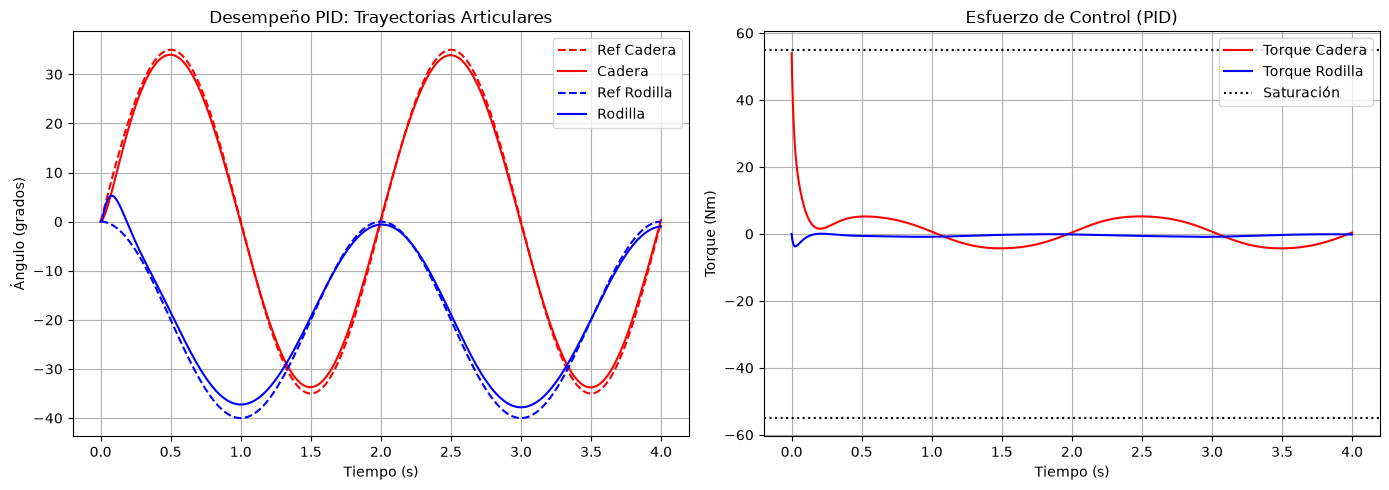

In [5]:
import control as ct
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros físicos e inicialización
m_th, m_sh = 3.3, 1.1           # Masas (kg)
l_th = 0.475                    # Longitud del muslo (m)
l_mt, l_ms = 0.360, 0.150       # Distancias a los CoM (m)
I_th, I_sh = 0.062, 0.018       # Inercias en el eje Y (kg*m^2)
g = 9.81                    # m/s^2

TAU_MAX = np.array([55.0, 55.0]) # Límite sociotécnico de seguridad (Nm)

# 2. Trayectorias de Marcha (2 ciclos en 4 segundos)
def referencia_marcha(t):
    theta_h_d = np.deg2rad(35) * np.sin(np.pi * t)
    theta_k_d = np.deg2rad(-40) * ((1 - np.cos(np.pi * t)) / 2)
    
    d_theta_h_d = np.deg2rad(35) * np.pi * np.cos(np.pi * t)
    d_theta_k_d = np.deg2rad(-40) * (np.pi / 2) * np.sin(np.pi * t)
    
    return np.array([theta_h_d, theta_k_d]), np.array([d_theta_h_d, d_theta_k_d])

# 3. Diseño Matemático del PID (Aproximación a Segundo Orden)
# Calculamos la inercia equivalente (J_eq) vista por cada actuador
# Cadera: Evaluamos M11 en la postura de mayor inercia (rodilla estirada, theta_k = 0)
J_eq_h = m_th*l_mt**2 + I_th + m_sh*(l_th**2 + l_ms**2 + 2*l_th*l_ms*np.cos(0)) + I_sh
# Rodilla: M22 es constante independiente de la postura
J_eq_k = m_sh*l_ms**2 + I_sh

# Definición de polos deseados (Desempeño exigido)
zeta = 1.0       # Críticamente amortiguado para evitar oscilaciones peligrosas
wn_h = 15.0      # Frecuencia natural de la cadera (rad/s)
wn_k = 18.0      # Frecuencia natural de la rodilla (rad/s)

# Cálculo formal de ganancias mediante igualación de polinomios
Kp_h = J_eq_h * (wn_h**2)
Kd_h = 2 * zeta * wn_h * J_eq_h
Ki_h = Kp_h / 3.0  # Ajuste heurístico para rechazo de perturbación gravitacional

Kp_k = J_eq_k * (wn_k**2)
Kd_k = 2 * zeta * wn_k * J_eq_k
Ki_k = Kp_k / 3.0

# Agrupamos las ganancias en arreglos vectoriales para la simulación
Kp = np.array([Kp_h, Kp_k])
Ki = np.array([Ki_h, Ki_k])
Kd = np.array([Kd_h, Kd_k])

print("--- GANANCIAS DEL PID CALCULADAS ANALÍTICAMENTE ---")
print(f"Cadera  -> Kp: {Kp[0]:.2f}, Ki: {Ki[0]:.2f}, Kd: {Kd[0]:.2f}")
print(f"Rodilla -> Kp: {Kp[1]:.2f}, Ki: {Ki[1]:.2f}, Kd: {Kd[1]:.2f}\n")

# 4. Simulación del Modelo Dinámico No Lineal con PID
dt = 0.001 # Paso de tiempo reducido para mayor estabilidad numérica
T_sim = 4.0
time_steps = np.arange(0, T_sim, dt)

# Vector de Estado: [theta_h, theta_k, dtheta_h, dtheta_k, error_integral_h, error_integral_k]
states = [np.zeros(6)]
torques = []

for i, t in enumerate(time_steps[:-1]):
    q = states[-1][0:2]
    dq = states[-1][2:4]
    int_e = states[-1][4:6]
    
    theta_h, theta_k = q[0], q[1]
    
    # Reconstrucción de la Dinámica M(q)
    M11 = m_th*l_mt**2 + I_th + m_sh*(l_th**2 + l_ms**2 + 2*l_th*l_ms*np.cos(theta_k)) + I_sh
    M12 = -m_sh*(l_ms**2 + l_th*l_ms*np.cos(theta_k)) - I_sh
    M = np.array([[M11, M12], [M12, m_sh*l_ms**2 + I_sh]])
    
    # Vector Gravedad G(q) explícito
    G_vec = np.array([
        g * m_th * l_mt * np.sin(theta_h) + g * m_sh * (l_th * np.sin(theta_h) + l_ms * np.sin(theta_h - theta_k)),
        -g * m_sh * l_ms * np.sin(theta_h - theta_k)
    ])
    
    C_dq = np.zeros(2) 
    
    # Cálculo del Error
    q_ref, dq_ref = referencia_marcha(t)
    error = q_ref - q
    error_dot = dq_ref - dq
    
    # Ley de Control PID con Saturación
    tau = Kp * error + Ki * int_e + Kd * error_dot
    tau_sat = np.clip(tau, -TAU_MAX, TAU_MAX)
    
    # Integración Anti-windup
    d_int_e = np.where(tau == tau_sat, error, 0)
    
    # Aceleración articular resolviendo la dinámica
    ddq = np.linalg.inv(M) @ (tau_sat - C_dq - G_vec)
    
    # Avance de estado por integración de Euler
    next_state = states[-1] + np.concatenate((dq, ddq, d_int_e)) * dt
    states.append(next_state)
    torques.append(tau_sat)

# Ajuste dimensional final
torques.append(torques[-1])
states = np.array(states)
torques = np.array(torques)

# 5. Métricas Cuantitativas Requeridas
q_act = states[:, 0:2]
q_ref = np.array([referencia_marcha(t)[0] for t in time_steps])
errores = q_ref - q_act

mae = np.mean(np.abs(errores), axis=0)
rmse = np.sqrt(np.mean(errores**2, axis=0))
u_rms = np.sqrt(np.mean(torques**2, axis=0))
u_max = np.max(np.abs(torques), axis=0)

print("--- RESULTADOS EXPERIMENTO 3: PID ---")
print(f"MAE Cadera: {np.rad2deg(mae[0]):.2f}°, Rodilla: {np.rad2deg(mae[1]):.2f}°")
print(f"RMSE Cadera: {np.rad2deg(rmse[0]):.2f}°, Rodilla: {np.rad2deg(rmse[1]):.2f}°")
print(f"Esfuerzo RMS Cadera: {u_rms[0]:.2f} Nm, Rodilla: {u_rms[1]:.2f} Nm")
print(f"Esfuerzo Máximo Cadera: {u_max[0]:.2f} Nm, Rodilla: {u_max[1]:.2f} Nm")

# 6. Visualización
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(time_steps, np.rad2deg(q_ref[:, 0]), 'r--', label='Ref Cadera')
plt.plot(time_steps, np.rad2deg(q_act[:, 0]), 'r', label='Cadera')
plt.plot(time_steps, np.rad2deg(q_ref[:, 1]), 'b--', label='Ref Rodilla')
plt.plot(time_steps, np.rad2deg(q_act[:, 1]), 'b', label='Rodilla')
plt.title("Desempeño PID: Trayectorias Articulares")
plt.xlabel("Tiempo (s)"); plt.ylabel("Ángulo (grados)")
plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
plt.plot(time_steps, torques[:, 0], 'r', label='Torque Cadera')
plt.plot(time_steps, torques[:, 1], 'b', label='Torque Rodilla')
plt.axhline(TAU_MAX[0], color='k', linestyle=':', label='Saturación')
plt.axhline(-TAU_MAX[0], color='k', linestyle=':')
plt.title("Esfuerzo de Control (PID)")
plt.xlabel("Tiempo (s)"); plt.ylabel("Torque (Nm)")
plt.legend(); plt.grid()

plt.tight_layout()
plt.show()

## Simulación

In [6]:
import mujoco
import mediapy as media
import numpy as np

# 1. Definición del Modelo XML (Geometría compartida por el equipo)
xml_string = """
<mujoco model="exoesqueleto_planar_estados">
  <compiler angle="radian" coordinate="local"/>
  <option gravity="0 0 -9.81" timestep="0.002"/>
  
  <visual>
    <global offwidth="1920" offheight="1080"/>
  </visual>

  <asset>
    <material name="thigh_mat" rgba="0.2 0.6 0.8 1"/>
    <material name="shank_mat" rgba="0.8 0.3 0.3 1"/>
    <texture type="skybox" builtin="gradient" rgb1="1 1 1" rgb2="0.6 0.8 1" width="512" height="512"/>
    <texture name="grid" type="2d" builtin="checker" rgb1="0.9 0.9 0.9" rgb2="0.7 0.7 0.7" width="512" height="512"/>
    <material name="grid_mat" texture="grid" texrepeat="5 5"/>
  </asset>

  <worldbody>
    <light pos="0 -2 2" dir="0 1 -1"/>
    <geom type="plane" size="2 2 0.1" pos="0 0 0" material="grid_mat"/>
    
    <body name="base" pos="0 0 1.2">
      <body name="thigh" pos="0 0 0">
        <joint name="hip" type="hinge" axis="0 -1 0" pos="0 0 0"/>
        <inertial pos="0 0 -0.360" mass="3.3" diaginertia="0.062 0.062 0.005"/>
        <geom type="capsule" size="0.04" fromto="0 0 0 0 0 -0.475" material="thigh_mat"/>

        <body name="shank" pos="0 0 -0.475">
          <joint name="knee" type="hinge" axis="0 -1 0" pos="0 0 0"/>
          <inertial pos="0 0 -0.150" mass="1.1" diaginertia="0.018 0.018 0.002"/>
          <geom type="capsule" size="0.03" fromto="0 0 0 0 0 -0.450" material="shank_mat"/>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <motor name="tau_h" joint="hip" gear="1" ctrllimited="true" ctrlrange="-50 50"/>
    <motor name="tau_k" joint="knee" gear="1" ctrllimited="true" ctrlrange="-50 50"/>
  </actuator>
</mujoco>
"""

# 2. Funciones de Trayectoria de Marcha (Posición y Velocidad)
def referencia_marcha(t):
    # Posiciones deseadas
    theta_h_d = np.deg2rad(35) * np.sin(np.pi * t)
    theta_k_d = np.deg2rad(-40) * ((1 - np.cos(np.pi * t)) / 2)
    # Velocidades deseadas
    d_theta_h_d = np.deg2rad(35) * np.pi * np.cos(np.pi * t)
    d_theta_k_d = np.deg2rad(-40) * (np.pi / 2) * np.sin(np.pi * t)
    return np.array([theta_h_d, theta_k_d]), np.array([d_theta_h_d, d_theta_k_d])

# 3. Diseño Matemático del PID adaptado a las masas reales del XML de MuJoCo
# Extraemos los parámetros físicos directamente de las etiquetas <inertial> y <geom>
m_th, m_sh = 3.3, 1.1           # Masas (kg)
l_th = 0.475                    # Longitud del muslo (m)
l_mt, l_ms = 0.360, 0.150       # Distancias a los CoM (m)
I_th, I_sh = 0.062, 0.018       # Inercias en el eje Y (kg*m^2)

TAU_MAX = 50.0 # Límite definido en las etiquetas <motor ctrlrange="-50 50">

# Inercia equivalente máxima para cada articulación
J_eq_h = m_th*l_mt**2 + I_th + m_sh*(l_th**2 + l_ms**2 + 2*l_th*l_ms*1.0) + I_sh
J_eq_k = m_sh*l_ms**2 + I_sh

# Desempeño exigido (Mismos polos de la sintonía analítica)
zeta = 1.0       
wn_h, wn_k = 15.0, 18.0      

# Cálculo de las nuevas ganancias
Kp_h = J_eq_h * (wn_h**2)
Kd_h = 2 * zeta * wn_h * J_eq_h
Ki_h = Kp_h / 3.0  

Kp_k = J_eq_k * (wn_k**2)
Kd_k = 2 * zeta * wn_k * J_eq_k
Ki_k = Kp_k / 3.0

Kp = np.array([Kp_h, Kp_k])
Ki = np.array([Ki_h, Ki_k])
Kd = np.array([Kd_h, Kd_k])

# 4. Inicialización del Entorno MuJoCo
model = mujoco.MjModel.from_xml_string(xml_string)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=480, width=640)

# Parámetros del bucle
T_sim = 4.0               # 4 segundos para 2 ciclos de marcha
dt = model.opt.timestep   # Paso de integración (0.002s por defecto según el XML)
framerate = 30            # FPS del video final
frames = []

# Variables de estado del controlador PID
int_e = np.zeros(2)       # Error integral acumulado

mujoco.mj_resetData(model, data)

# 5. Bucle de Simulación
while data.time < T_sim:
    t = data.time
    
    # 5.1 Lectura simulada de sensores articulares
    q_actual = np.array([data.qpos[0], data.qpos[1]])
    dq_actual = np.array([data.qvel[0], data.qvel[1]])
    
    # 5.2 Cálculo de la referencia y el error
    q_ref, dq_ref = referencia_marcha(t)
    
    error = q_ref - q_actual
    error_dot = dq_ref - dq_actual
    
    # 5.3 Ley de Control PID
    tau = Kp * error + Ki * int_e + Kd * error_dot
    
    # Saturación de los motores
    tau_sat = np.clip(tau, -TAU_MAX, TAU_MAX)
    
    # 5.4 Mecanismo Anti-windup y actualización de la integral (Método de Euler)
    # Solo integramos si el torque no está saturado
    d_int_e = np.where(tau == tau_sat, error, 0)
    int_e = int_e + d_int_e * dt
    
    # 5.5 Inyectamos el torque a los motores virtuales de MuJoCo
    data.ctrl[0] = tau_sat[0]
    data.ctrl[1] = tau_sat[1]
    
    # Avanzamos un paso de cálculo en el motor de física
    mujoco.mj_step(model, data)
    
    # Guardamos 1 frame cada 1/30 segundos para generar el video fluido
    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

print("Simulación completada. Procesando video...")
media.show_video(frames, fps=framerate)

Simulación completada. Procesando video...


This browser does not support the video tag.
